CRAZYFLIE
=========

In [1]:
import argparse
import cflib.crtp
from cflib.crtp.radio_link_statistics import RadioLinkStatistics
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.crazyflie.syncLogger import SyncLogger
from cflib.crazyflie.swarm import CachedCfFactory
from cflib.crazyflie.swarm import Swarm
import cflib.drivers.crazyradio as crazyradio
from cflib.positioning.motion_commander import MotionCommander

from cflib.utils import uri_helper
from cflib.utils.multiranger import Multiranger
from cflib.utils.reset_estimator import reset_estimator

from collections import defaultdict
from dotenv import load_dotenv
import logging
import numpy as np
import sys
from threading import Event
import time

# Data Visualization

In [2]:
# ------------------------------------
# ENVIRONMENT VARIABLES
# ------------------------------------
load_dotenv('')

# URI to the Crazyflie to connect to
URIs = []
for d in range(1,4):
    URIs.append( uri_helper.uri_from_env(env=f'DRONE{str(d)}_URI', default='radio://0/80/2M/E7E7E7E7E7') )
print(URIs)

['radio://0/80/2M/E7E7E7E701', 'radio://0/80/2M/E7E7E7E702', 'radio://0/95/2M/E7E7E7E703']


In [3]:
# ------------------------------------
# STATISTICS
# ------------------------------------
link_quality = 0
def radio_stats_cb(data):
    global link_quality
    link_quality = data
    
def link_error_cb(data):
    raise Exception

In [5]:
# ------------------------------------
# LOGGING
# ------------------------------------
logging.basicConfig(level=logging.ERROR)
print("Python Version", sys.version)
print(f"Crazyradio 2.0 Version: {crazyradio.Crazyradio().version}")

from collections import defaultdict

# Kalman Filter Logging Callback
t_kalman = []
kalman_logs = defaultdict(list)
def log_pos_cb(timestamp, data, logconf):
    global t_kalman
    global kalman_logs
    print('[%d][%s]: %s' % (timestamp, logconf.name, data))
    t_kalman.append(timestamp)
    kalman_logs['kalman.stateX'].append(data['kalman.stateX'])
    kalman_logs['kalman.stateY'].append(data['kalman.stateY'])
    kalman_logs['kalman.stateZ'].append(data['kalman.stateZ'])

# Radio RSSI Logging Callback
t_rssi = []
rssi_logs = []
def log_radio_cb(timestamp, data, logconf):
    pass#print('[%d][%s]: %s' % (timestamp, logconf.name, data))

# Multi-Ranger Logging Callback
t_range = []
range_logs = defaultdict(list)
def log_range_cb(timestamp, data, logconf):
    global t_range
    global range_logs
    print('[%d][%s]: %s' % (timestamp, logconf.name, data))
    t_range.append(timestamp)
    range_logs['range.front'].append(data['range.front'])
    range_logs['range.right'].append(data['range.right'])
    range_logs['range.back'].append(data['range.back'])
    range_logs['range.left'].append(data['range.left'])
    range_logs['range.zrange'].append(data['range.zrange'])

# Battery Logging Callback
battery_level = 0.0
def log_battery_cb(timestamp, data, logconf):
    global battery_level
    battery_level = data['pm.batteryLevel']

sup_info_lkp = { 
    0:("Can be armed", False), 
    1:("Is armed",False), 
    2:("Auto arm mode", False), 
    3:("Ready to fly", False), 
    4:("Is flying", False), 
    5:("Is tumbled", False), 
    6:("Is locked", False), 
    7:("Is crashed", False), 
    8:("HLC enabled", False), 
    9:("HLT Finished", False), 
    10:("HLC disabled", False)
}
def log_supervisor_cb(timestamp, data, logconf):
    global sup_info_lkp
    # Implement something to check all the cases

isFlying = 0
def log_sys_cb(timestamp, data, logconf):
    global isFlying
    isFlying = data['sys.isFlying']

def log_pos_cb2(timestamp, data, logconf):
    print("-" + " POSITION LOG " + "-" * 20)
    for key, value in data.items():
        print(f"{key}: {value:2.3f}",)
    print("\n-" + "--------------" + "-" * 20)

flag_header = False
def log_radio_cb2(timestamp, data, logconf):
    global flag_header
    global link_quality
    global rssi_logs
    
    if not flag_header:
        print("|-" + " RADIO LOG " + "-" * 20)
        print("| ", end='')
        print(f"Link Quality", end=' |\t')
        for key in data.keys():
            print(f"{key}", end=' |\t')
        print("")
        flag_header = True
    print("| ", end='')
    print(f"{link_quality:2.2f}", end=f'{' '*(12-1)}|\t')
    for key, value in data.items():
        rssi_logs.append(value) if key == 'radio.rssi' else None
        print(f"{value}", end=f'{' '*(len(key)-1)}|\t')
    print("")

def log_error_cb(logconf, msg):
    print("Error when logging %s" % logconf.name)

Python Version 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Crazyradio 2.0 Version: 5.4


In [6]:
# CrazyRadio devices currently connected to the computer
print("\n|- Crazyradio Devices ---" + "-" * 10)
dongles = []
for d in crazyradio._find_devices():
    print(f"|- \t{d.manufacturer}, {d.product} (Serial number: {d.serial_number})")
    dongles.append(d)
print("|------------------------" + "-" * 10)


|- Crazyradio Devices -------------
|- 	Bitcraze AB, Crazyradio 2.0 (Serial number: 57D5141CC2A4510C)
|----------------------------------


**Main**

In [7]:
radio = crazyradio.Crazyradio()

# Initialize the low-level drivers
cflib.crtp.init_drivers(enable_serial_driver=False)

# Interface status
interfaces = cflib.crtp.get_interfaces_status()
print(f"Radio Interface: {interfaces['radio']}")

Radio Interface: Crazyradio version 5.4


In [18]:
# Crazyradio Interface scanning
drones = dict() # Dictionary: { 'drone_uri': driverClass_uri}
for uri in URIs:
    drone_addr = uri.split('/')[-1]
    available = cflib.crtp.scan_interfaces(address=int(drone_addr, 16))
    if available:
        #drones.add(available[0][0])
        """
        drones[available[0][0]] = cflib.crtp.get_link_driver(
            uri=available[0][0], 
            #radio_link_statistics_callback=radio_stats_cb,
            link_error_callback=link_error_cb
        )
        """

        drones[available[0][0]] = 1
drones_uri = list(drones.keys())
print("Crazyflie available: ", drones_uri)

Crazyflie available:  ['radio://0/80/2M/E7E7E7E701']


In [19]:
drone_uri = drones_uri[0]
print("Link", drones[drone_uri])
cf_stats = Crazyflie(rw_cache='./cache')

Link 1


**Logging**

In [20]:
def log_configurations():
    logconf = []

    def log_radio_conf():
        log_conf = LogConfig(name="Radio", period_in_ms=500)
        log_conf.add_variable('radio.rssi', 'uint8_t') # Radio Signal Strength Indicator [dBm]
        log_conf.add_variable('radio.isConnected', 'uint8_t') # Indicator if a packet was received from the radio within the last RADIO_ACTIVITY_TIMEOUT_MS
        log_conf.add_variable('radio.numRxBc', 'uint16_t') # Number of broadcast packets received
        log_conf.add_variable('radio.numRxUc', 'uint16_t') # Number of unicast packets received
        return log_conf
    
    def log_pos_conf():
        log_conf = LogConfig(name='Position', period_in_ms=200)
        log_conf.add_variable('kalman.stateX', 'float')
        log_conf.add_variable('kalman.stateY', 'float')
        log_conf.add_variable('kalman.stateZ', 'float')
        return log_conf
    
    def log_range_conf():
        log_conf = LogConfig(name='Range', period_in_ms=200)
        log_type = 'uint16_t' # Distance from the sensor to an obstacle in mm
        log_conf.add_variable('range.front', 'uint16_t')
        log_conf.add_variable('range.back', 'uint16_t')
        log_conf.add_variable('range.left', 'uint16_t')
        log_conf.add_variable('range.right', 'uint16_t')
        log_conf.add_variable('range.zrange', 'uint16_t')
        return log_conf
    
    def log_battery_conf():
        log_conf = LogConfig(name='Battery', period_in_ms=1000)
        battery_type="uint8_t"
        log_conf.add_variable("pm.batteryLevel", battery_type)
        return log_conf
    
    def log_supervisor_conf():
        log_conf = LogConfig(name='Supervisor', period_in_ms=500)
        log_conf.add_variable('supervisor.info', 'uint16_t')
        return log_conf
    
    def log_sys_conf():
        log_conf = LogConfig(name='Sys', period_in_ms=500)
        log_conf.add_variable('sys.isFlying', 'uint8_t')
        return log_conf
        
    def log_imu_conf():
        log_conf = LogConfig(name='Position', period_in_ms=30)
        imu_type="FP16"
        log_conf.add_variable("acc.x", imu_type)
        log_conf.add_variable("acc.y", imu_type)
        log_conf.add_variable("acc.z", imu_type)
        log_conf.add_variable("gyro.x", imu_type)
        log_conf.add_variable("gyro.y", imu_type)
        log_conf.add_variable("gyro.z", imu_type)
        
    logconf.append( log_radio_conf() )
    logconf.append( log_pos_conf() )
    logconf.append( log_range_conf() )
    logconf.append( log_battery_conf() )
    logconf.append( log_sys_conf() )
    #logconf.append( log_supervisor_conf() )

    return logconf

In [ ]:
import asyncio

print("|--- SyncCrazyflie ---|")
scf = SyncCrazyflie(drone_uri, cf=cf_stats)
print("|- 1. Open Link")
scf.open_link()

# ---[ Logs configuration ]---
print("|- 2. Log Configurations ", end=': ')
log_configs = log_configurations()
print([log_conf.name for log_conf in log_configs])

mc = False
multi_ranger = False

async def func1():
    # Log configuration to logging framework
    for log_conf in log_configs:
        
        scf.cf.log.add_config(log_conf)

        if log_conf.valid:
            print(f"|- 2. Loading {log_conf.name}")
            
            scf.cf.link_statistics.link_quality_updated.add_callback(radio_stats_cb)
            match(log_conf.name):
                case "Radio":
                    log_conf.data_received_cb.add_callback(log_radio_cb)
                case "Position":
                    log_conf.data_received_cb.add_callback(log_pos_cb)
                case "Range":
                    log_conf.data_received_cb.add_callback(log_range_cb)
                case "Battery":
                    log_conf.data_received_cb.add_callback(log_battery_cb)
                case "Sys":
                    log_conf.data_received_cb.add_callback(log_sys_cb)
                case "Supervisor":
                    log_conf.data_received_cb.add_callback(log_supervisor_cb)
            
            log_conf.error_cb.add_callback(log_error_cb)
        else:
            print("One or more of the variables in the configuration was not found in log TOC. No logging will be possible.")

    # ---[ Parameter configuration ]---
    print("|- 3.1 Wait for params...")
    scf.wait_for_params()

    # Activate mellinger controller
    scf.cf.param.set_value('stabilizer.controller', '0')

    # Stabilizer - Controller checks - https://www.bitcraze.io/documentation/repository/crazyflie-firmware/master/functional-areas/sensor-to-control/controllers/
    def param_controller(_, value_str):
        group, name = _.split(".")
        controller_type = {0:"Auto select", 1:"PID", 2:"Mellinger", 3:"INDI", 4:"Brescianini", 5:"Lee"}
        value = int(value_str)
        print(f"[{group}]: {name} \"{controller_type[value]} ({value})\" is used!")
            
    scf.cf.param.add_update_callback(group="stabilizer", name="controller", cb=param_controller)


    # Reset estimator
    print("|- 3.2 Wait for reset estimator...", end=' ')
    reset_estimator(scf) # resets the Kalman filter and makes the Crazyflie wait until it has an accurate position estimate
    time.sleep(1)

    #scf.cf.link_statistics.link_quality_updated.add_callback(link_quality_cb)
    #scf.cf.link_statistics.stop()
    for log_conf in log_configs:
        log_conf.start()

await func1()

|--- SyncCrazyflie ---|
|- 1. Open Link
|- 2. Log Configurations : ['Radio', 'Position', 'Range', 'Battery', 'Sys']
|- 2. Loading Radio
|- 2. Loading Position
|- 2. Loading Range
|- 2. Loading Battery
|- 2. Loading Sys
|- 3.1 Wait for params...
|- 3.2 Wait for reset estimator... [stabilizer]: controller "Auto select (0)" is used!
Waiting for estimator to find position...success!


[272225][Position]: {'kalman.stateX': -0.00013478616892825812, 'kalman.stateY': 0.0002103280130540952, 'kalman.stateZ': 0.01119497511535883}
[272225][Range]: {'range.front': 32766, 'range.back': 1366, 'range.left': 341, 'range.right': 319, 'range.zrange': 11}
[272426][Position]: {'kalman.stateX': 0.0003466462076175958, 'kalman.stateY': 1.4053929362489725e-06, 'kalman.stateZ': 0.01154965627938509}
[272426][Range]: {'range.front': 32766, 'range.back': 1362, 'range.left': 329, 'range.right': 317, 'range.zrange': 13}
[272625][Position]: {'kalman.stateX': 0.0005448946612887084, 'kalman.stateY': 0.0014786140527576208, 'kalman.stateZ': 0.011298020370304585}
[272625][Range]: {'range.front': 32766, 'range.back': 1362, 'range.left': 32766, 'range.right': 313, 'range.zrange': 10}
[272825][Position]: {'kalman.stateX': 0.00037519808392971754, 'kalman.stateY': 0.0017466293647885323, 'kalman.stateZ': 0.010288438759744167}
[272825][Range]: {'range.front': 32766, 'range.back': 1367, 'range.left': 32766

In [17]:
for log_conf in log_configs:
    log_conf.stop()
scf.close_link()

In [ ]:
if not mc:
    print("|- 4. MOTION COMMANDER CONTROL", end='\n|-----------------------------')
    mc = MotionCommander(scf.cf, default_height=0.5)
else:
    pass

|- 4. MOTION COMMANDER CONTROL
|-----------------------------

[279025][Position]: {'kalman.stateX': 0.000472071988042444, 'kalman.stateY': 0.0008880621753633022, 'kalman.stateZ': 0.010491636581718922}
[279025][Range]: {'range.front': 32766, 'range.back': 1365, 'range.left': 341, 'range.right': 314, 'range.zrange': 9}
[279225][Position]: {'kalman.stateX': -9.786726877791807e-06, 'kalman.stateY': 0.0001599007227923721, 'kalman.stateZ': 0.01070449035614729}
[279225][Range]: {'range.front': 32766, 'range.back': 1365, 'range.left': 340, 'range.right': 313, 'range.zrange': 12}
[279425][Position]: {'kalman.stateX': 0.00045772764133289456, 'kalman.stateY': 0.0006430058856494725, 'kalman.stateZ': 0.010582741349935532}
[279425][Range]: {'range.front': 32766, 'range.back': 1373, 'range.left': 32766, 'range.right': 320, 'range.zrange': 11}
[279625][Position]: {'kalman.stateX': 0.00022269171313382685, 'kalman.stateY': 0.0006491587264463305, 'kalman.stateZ': 0.012217046692967415}
[279625][Range]: {'range.front': 32766, 'range.back': 1365, 'range.left': 32766, 

In [ ]:
if not isFlying:
    print("|- 4.1 MC > Take Off")
    mc.take_off()

elif not multi_ranger:
    print("|- 4.2 Multi-Ranger Setup")
    multi_ranger = Multiranger(scf, rate_ms=200, zranger=True)

    # 2 - Pre-Configuration: Multi-Ranger Distance, Flow Deck Height
    def is_close(range):
        MIN_DISTANCE = 0.2  # m

        if range is None:
            return False
        else:
            return range < MIN_DISTANCE

    keep_flying = True
    while keep_flying:
        VELOCITY = 0.3
        velocity_x = 0.0
        velocity_y = 0.0

        if is_close(multi_ranger.front):
            velocity_x -= VELOCITY
        if is_close(multi_ranger.back):
            velocity_x += VELOCITY

        if is_close(multi_ranger.left):
            velocity_y -= VELOCITY
        if is_close(multi_ranger.right):
            velocity_y += VELOCITY

        if is_close(multi_ranger.up):
            keep_flying = False

        mc.start_linear_motion(
            velocity_x_m=velocity_x, 
            velocity_y_m=velocity_y, 
            velocity_z_m=0,
            rate_yaw=0
        )
        time.sleep(0.1)

    mc.land()
else:
    print("SONO QUI")
    pass

|- 4.1 MC > Take Off


[366025][Position]: {'kalman.stateX': -0.0008969784248620272, 'kalman.stateY': 0.00013890463742427528, 'kalman.stateZ': 0.012086235918104649}
[366025][Range]: {'range.front': 32766, 'range.back': 32766, 'range.left': 32766, 'range.right': 315, 'range.zrange': 13}
[366225][Position]: {'kalman.stateX': -0.0015687322011217475, 'kalman.stateY': -3.370652120793238e-05, 'kalman.stateZ': 0.011172712780535221}
[366225][Range]: {'range.front': 32766, 'range.back': 1048, 'range.left': 32766, 'range.right': 316, 'range.zrange': 10}
[366426][Position]: {'kalman.stateX': -0.0015533053083345294, 'kalman.stateY': -5.011224857298657e-05, 'kalman.stateZ': 0.012718516401946545}
[366426][Range]: {'range.front': 32766, 'range.back': 1028, 'range.left': 32766, 'range.right': 310, 'range.zrange': 15}
[366625][Position]: {'kalman.stateX': -0.0005965131567791104, 'kalman.stateY': 0.00019218309898860753, 'kalman.stateZ': 0.012190747074782848}
[366625][Range]: {'range.front': 32766, 'range.back': 994, 'range.le

In [ ]:
print("|- 4.2 Multi-Ranger Setup")
multi_ranger = Multiranger(scf, rate_ms=200, zranger=True)

# 2 - Pre-Configuration: Multi-Ranger Distance, Flow Deck Height
def is_close(range):
    MIN_DISTANCE = 0.2  # m

    if range is None:
        return False
    else:
        return range < MIN_DISTANCE

keep_flying = True
while keep_flying:
    VELOCITY = 0.3
    velocity_x = 0.0
    velocity_y = 0.0

    if is_close(multi_ranger.front):
        velocity_x -= VELOCITY
    if is_close(multi_ranger.back):
        velocity_x += VELOCITY

    if is_close(multi_ranger.left):
        velocity_y -= VELOCITY
    if is_close(multi_ranger.right):
        velocity_y += VELOCITY

    if is_close(multi_ranger.up):
        keep_flying = False

    mc.start_linear_motion(
        velocity_x_m=velocity_x, 
        velocity_y_m=velocity_y, 
        velocity_z_m=0,
        rate_yaw=0
    )
    time.sleep(0.1)

mc.land()


|- 4.1 MC > Take Off
[221395][Position]: {'kalman.stateX': 0.0002937719691544771, 'kalman.stateY': -0.0004724278987850994, 'kalman.stateZ': 0.012991989962756634}
[221397][Range]: {'range.front': 32766, 'range.back': 32766, 'range.left': 32766, 'range.right': 151, 'range.zrange': 13}
[221595][Position]: {'kalman.stateX': -0.00043762457789853215, 'kalman.stateY': -0.00041862716898322105, 'kalman.stateZ': 0.015498654916882515}
[221597][Range]: {'range.front': 32766, 'range.back': 32766, 'range.left': 32766, 'range.right': 154, 'range.zrange': 16}
[221795][Position]: {'kalman.stateX': 0.0002479030517861247, 'kalman.stateY': 0.0006197960465215147, 'kalman.stateZ': 0.01572432368993759}
[221797][Range]: {'range.front': 32766, 'range.back': 32766, 'range.left': 32766, 'range.right': 150, 'range.zrange': 15}
[221995][Position]: {'kalman.stateX': -0.004574519116431475, 'kalman.stateY': 0.002965350402519107, 'kalman.stateZ': 0.015996145084500313}
[221997][Range]: {'range.front': 32766, 'range.bac

KeyboardInterrupt: 

In [13]:
keep_flying = False

[182932][Position]: {'kalman.stateX': -0.044199246913194656, 'kalman.stateY': 0.040721409022808075, 'kalman.stateZ': 0.18347056210041046}
[182933][Range]: {'range.front': 32766, 'range.back': 1333, 'range.left': 32766, 'range.right': 32766, 'range.zrange': 184}
[183132][Position]: {'kalman.stateX': -0.04540132358670235, 'kalman.stateY': 0.040479518473148346, 'kalman.stateZ': 0.18371227383613586}
[183133][Range]: {'range.front': 32766, 'range.back': 1331, 'range.left': 32766, 'range.right': 32766, 'range.zrange': 184}
[183332][Position]: {'kalman.stateX': -0.04627716913819313, 'kalman.stateY': 0.040265120565891266, 'kalman.stateZ': 0.1846836656332016}
[183333][Range]: {'range.front': 32766, 'range.back': 1327, 'range.left': 32766, 'range.right': 32766, 'range.zrange': 187}
[183532][Position]: {'kalman.stateX': -0.04708731174468994, 'kalman.stateY': 0.04010891169309616, 'kalman.stateZ': 0.18394188582897186}
[183533][Range]: {'range.front': 32766, 'range.back': 1330, 'range.left': 32766, 

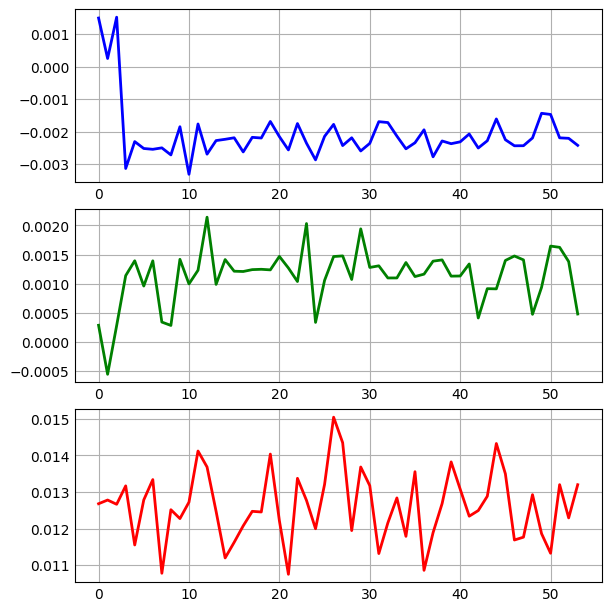

In [23]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('_mpl-gallery')

# plot
t1 = range(0,len(kalman_logs['kalman.stateX']))
t2 = range(0,len(kalman_logs['kalman.stateY']))
t3 = range(0,len(kalman_logs['kalman.stateZ']))
tt = [t3, t2, t1]
states = [kalman_logs['kalman.stateZ'], kalman_logs['kalman.stateY'], kalman_logs['kalman.stateX']]
colors = ['red', 'green', 'blue']

fig, axs = plt.subplots(3, 1, layout='constrained', figsize=(6, 6))
for nn, ax in enumerate(axs):
    t = tt.pop()
    state = states.pop()
    color = colors.pop()
    ax.plot(t, state, linewidth=2.0, color=color)

plt.show()

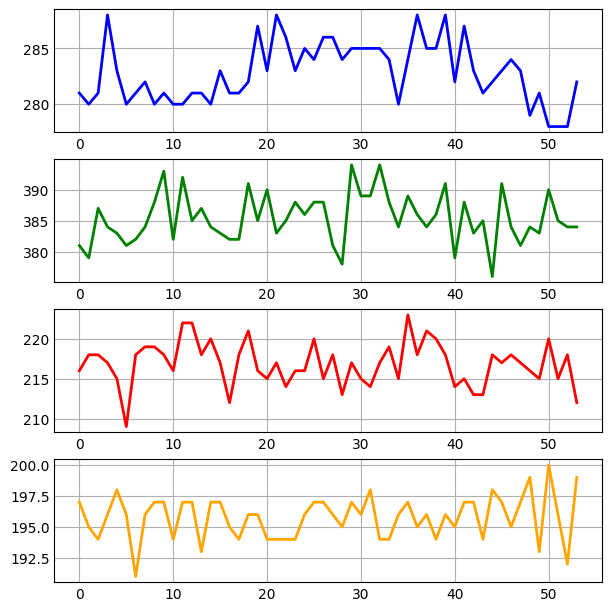

In [24]:
# plot
t1 = range(0,len(range_logs['range.left']))
t2 = range(0,len(range_logs['range.right']))
t3 = range(0,len(range_logs['range.front']))
t4 = range(0,len(range_logs['range.back']))
tt = [t4, t3, t2, t1]
states = [
    range_logs['range.left'], 
    range_logs['range.right'], 
    range_logs['range.front'],
    range_logs['range.back']
]
colors = ['orange', 'red', 'green', 'blue']

fig, axs = plt.subplots(4, 1, layout='constrained', figsize=(6, 6))
for nn, ax in enumerate(axs):
    t = tt.pop()
    state = states.pop()
    color = colors.pop()
    ax.plot(t, state, linewidth=2.0, color=color)

plt.show()

In [31]:
# 2 Hz (200 ms)
#print(t_kalman)
t_kalman.index(t_kalman[-2])

52

In [32]:
len(t_kalman)

54

In [ ]:
import random
import time
from collections import defaultdict
import pprint

def generator_kalman(seed=1.0):
    log = {'kalman.stateX': random.random(), 'kalman.stateY': random.random(), 'kalman.stateZ': random.random()}
    yield log

logs = defaultdict(list)
while True:
    try:
        new_entry = next(generator_kalman())                
        logs['kalman.stateX'].append(new_entry['kalman.stateX'])
        logs['kalman.stateY'].append(new_entry['kalman.stateY'])
        logs['kalman.stateZ'].append(new_entry['kalman.stateZ'])
        time.sleep(0.8)
    except KeyboardInterrupt:
        break

pprint.pp(logs)